# Taller B3-T4 — Redes Neuronales para Forecasting
## Ventana entrada: 5 dias | Ventana salida: 90 dias

**Caso sal90 - target promedio 90 dias** — Target = media de 90 dias de retornos log. Maximo suavizado: el target captura tendencia trimestral, casi-determinista. Solo 5 dias de input es muy poca informacion para predecir 90 dias, por eso el baseline Buy & Hold es muy competitivo. Capacidad media con regularizacion moderada y prediccion centrada en niveles medios.

Las funciones de construccion vienen de `utilidades/modelos.py`:
- `construir_dense_v18_E`        (MLP wide 128->32 con LayerNorm, lr 3e-4, dropout 0.3, L2 2e-4)
- `construir_recurrente_v18_E`        (Bidirectional LSTM 20 + GAP cross-time, dropout 0.3)
- `construir_conv1d_v16_E`        (multi-kernel paralelo (1,3,5) x 10 filtros + GAP, lr 3e-4, dropout 0.3)
- `construir_mixto_v17_E`        (TimeDistributed(Dense 20) + BiGRU 12 + Dense 24, dropout 0.3)

- **Parte 1 — Competicion**: entrenar y comparar modelos sobre log-retornos en bruto
- **Parte 2 — Investigacion**: aplicar preprocesado del Taller B3-T1 (Lopez de Prado) y evaluar su efecto


In [1]:
VENTANA_ENTRADA = 5   # dias de entrada
VENTANA_SALIDA  = 90   # dias de salida (promedio)


In [2]:
import sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize_scalar
from sklearn.neighbors import KernelDensity
from statsmodels.tsa.stattools import adfuller
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback
from keras.layers import LayerNormalization
from IPython.display import clear_output
from utilidades.carga_datos  import cargar_retornos, create_time_series_data, dividir_datos, aplanar_X
from utilidades.modelos      import *                              # baselines + variantes ajustadas por random search
from utilidades.modelos      import (                              # imports explicitos de las versiones usadas
    construir_dense_v18_E,
    construir_recurrente_v18_E,
    construir_conv1d_v16_E,
    construir_mixto_v17_E,
)
from utilidades.evaluacion   import evaluar_modelo, evaluar_sklearn, evaluar_buyhold, guardar_resultados
from utilidades.graficos     import graficar_convergencia, graficar_barras_mae


In [3]:
class LivePlot(Callback):
    """Dibuja la curva de convergencia en directo tras cada epoca."""
    def __init__(self, nombre_modelo='Modelo'):
        super().__init__()
        self.nombre_modelo = nombre_modelo
    def on_train_begin(self, logs=None):
        self.train_losses = []
        self.val_losses   = []
    def on_epoch_end(self, epoch, logs=None):
        self.train_losses.append(logs.get('loss'))
        self.val_losses.append(logs.get('val_loss'))
        if epoch < 2:
            return
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(self.train_losses, label='Train')
        ax.plot(self.val_losses,   label='Validacion')
        ax.set_xlabel('Epoca')
        ax.set_ylabel('MAE')
        ax.set_title(
            f'{self.nombre_modelo} — Epoca {epoch+1} | '
            f'Train: {self.train_losses[-1]:.5f} | '
            f'Val: {self.val_losses[-1]:.5f}'
        )
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


class HistoriaParcial:
    """Imita el objeto History de Keras a partir de un LivePlot interrumpido."""
    def __init__(self, callback_liveplot):
        self.history = {
            'loss':     list(callback_liveplot.train_losses),
            'val_loss': list(callback_liveplot.val_losses),
        }

class MejoresPesos(Callback):
    """Guarda los pesos de la epoca con menor val_loss y los restaura al final.
    Equivalente al restore_best_weights de EarlyStopping pero sin parar."""
    def __init__(self, monitor='val_loss'):
        super().__init__()
        self.monitor = monitor
    def on_train_begin(self, logs=None):
        self.mejor_valor  = float('inf')
        self.mejores_pesos = None
        self.mejor_epoca   = 0
    def on_epoch_end(self, epoch, logs=None):
        valor = logs.get(self.monitor)
        if valor is not None and valor < self.mejor_valor:
            self.mejor_valor   = valor
            self.mejores_pesos = self.model.get_weights()
            self.mejor_epoca   = epoch + 1
    def restaurar(self):
        """Restaura en el modelo los mejores pesos guardados."""
        if self.mejores_pesos is not None:
            self.model.set_weights(self.mejores_pesos)
            print(f'  → Pesos restaurados de epoca {self.mejor_epoca} '
                  f'(val_loss = {self.mejor_valor:.5f})')
        else:
            print('  → Aun no hay epoca completada; pesos actuales conservados.')

def fit_interrumpible(modelo, X, y, validation_data, epochs, batch_size,
                      callbacks, verbose=0):
    """Wrapper de model.fit() que captura KeyboardInterrupt y devuelve
    siempre un objeto con .history utilizable por graficar_convergencia.
    Tras el entrenamiento (termine o se interrumpa) restaura los mejores
    pesos a partir del callback MejoresPesos si esta presente."""
    try:
        hist = modelo.fit(X, y, validation_data=validation_data,
                          epochs=epochs, batch_size=batch_size,
                          callbacks=callbacks, verbose=verbose)
        interrumpido = False
    except KeyboardInterrupt:
        print('\n[INTERRUMPIDO] Reconstruyendo historia...')
        liveplot = next(c for c in callbacks if isinstance(c, LivePlot))
        hist = HistoriaParcial(liveplot)
        interrumpido = True
    # Restaurar mejores pesos si el callback esta presente
    mejor = next((c for c in callbacks if isinstance(c, MejoresPesos)), None)
    if mejor is not None:
        mejor.restaurar()
    if interrumpido:
        print('  Listo. Puedes evaluar el modelo en la siguiente celda.')
    return hist


---
# PARTE 1 — Competicion
Modelos sobre log-retornos en bruto. Metrica: MAE medio sobre 23 activos.


## 1.1 Carga de datos

In [4]:
retornos = cargar_retornos()
X, y = create_time_series_data(retornos, VENTANA_ENTRADA, VENTANA_SALIDA)
print(f'X: {X.shape}  |  y: {y.shape}')
X_train, X_val, X_test, y_train, y_val, y_test = dividir_datos(X, y)

X_train_plano = aplanar_X(X_train)
X_val_plano   = aplanar_X(X_val)
X_test_plano  = aplanar_X(X_test)

# Normalizar inputs: sin esto los gradientes son ~1e-6 y los modelos se rinden
# tras pocas epocas (Conv1D restauraba pesos de la epoca 3).
scaler = StandardScaler()
X_train_plano = scaler.fit_transform(X_train_plano)
X_val_plano   = scaler.transform(X_val_plano)
X_test_plano  = scaler.transform(X_test_plano)
X_train = X_train_plano.reshape(X_train.shape)
X_val   = X_val_plano.reshape(X_val.shape)
X_test  = X_test_plano.reshape(X_test.shape)

print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')
print(f'Tras normalizar: media={X_train.mean():.4f}  std={X_train.std():.4f}')


X: (16096, 5, 23)  |  y: (16096, 23)
Train: (13761, 5, 23)  Val: (725, 5, 23)  Test: (1610, 5, 23)
Tras normalizar: media=0.0000  std=1.0000


## 1.2 Baselines

In [5]:
reg_lineal = LinearRegression()
reg_lineal.fit(X_train_plano, y_train)
resultado_lineal = evaluar_sklearn(
    reg_lineal, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Lineal')
resultado_bah = evaluar_buyhold(y_train, y_val, y_test)
print(pd.DataFrame([resultado_lineal, resultado_bah]).set_index('modelo').round(6))


            mae_train   mae_val  mae_test  n_params
modelo                                             
Lineal       0.001241  0.001002  0.001273         0
BuyAndHold   0.001246  0.000998  0.001265         0


## 1.3 Modelo Dense (MLP)

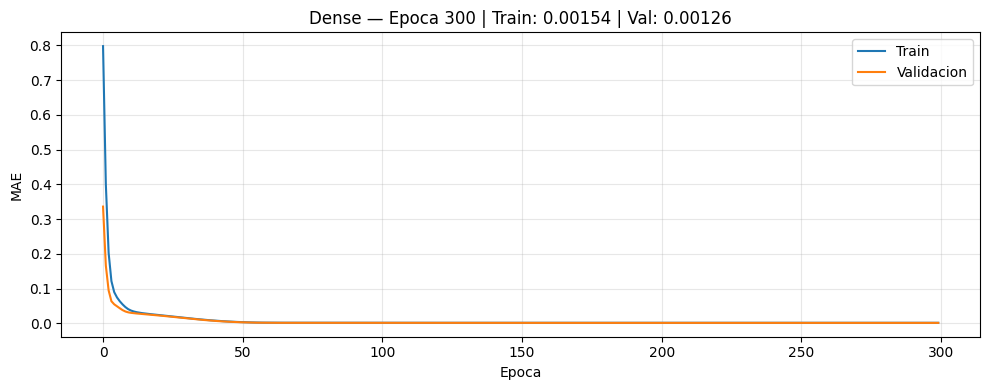

  → Pesos restaurados de epoca 298 (val_loss = 0.00126)


In [6]:
modelo_dense = construir_dense_v18_E(X_train_plano.shape[1], y_train.shape[1])
modelo_dense.summary()
callbacks_dense = [
    MejoresPesos(),
    ReduceLROnPlateau(factor=0.5, patience=10, min_lr=1e-6, verbose=0),
    LivePlot('Dense'),
]
hist_dense = fit_interrumpible(
    modelo_dense, X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=300, batch_size=128,
    callbacks=callbacks_dense, verbose=0)


{'modelo': 'Dense', 'mae_train': 0.0012433900340738115, 'mae_val': 0.0009954223309885852, 'mae_test': 0.001262996072275704, 'n_params': 19991}


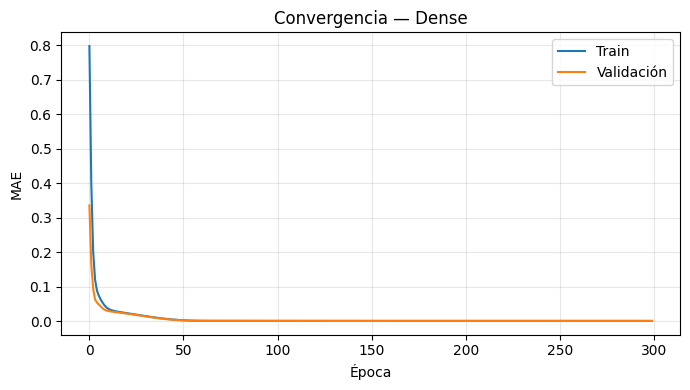

In [7]:
graficar_convergencia(hist_dense, 'Dense')
resultado_dense = evaluar_modelo(modelo_dense, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense')
print(resultado_dense)


## 1.4 Modelo Recurrente (LSTM)

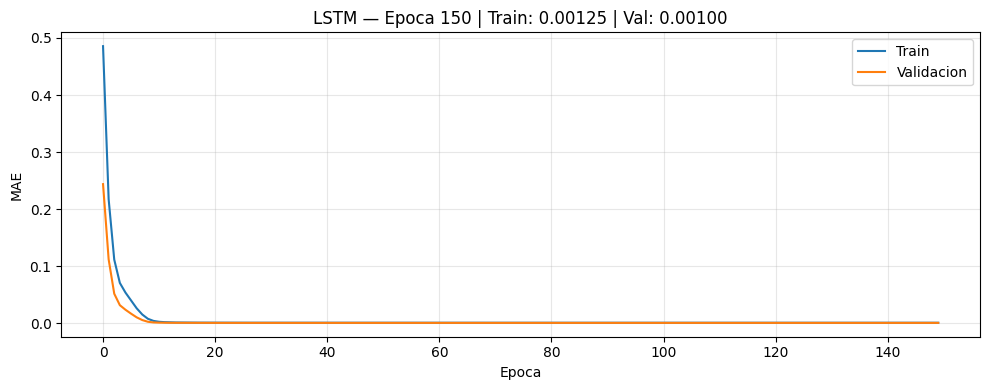

  → Pesos restaurados de epoca 28 (val_loss = 0.00099)


In [8]:
modelo_lstm = construir_recurrente_v18_E(X_train.shape[1:], y_train.shape[1])
modelo_lstm.summary()
callbacks_lstm = [
    MejoresPesos(),
    ReduceLROnPlateau(factor=0.5, patience=10, min_lr=1e-6, verbose=0),
    LivePlot('LSTM'),
]
hist_lstm = fit_interrumpible(
    modelo_lstm, X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150, batch_size=128,
    callbacks=callbacks_lstm, verbose=0)


{'modelo': 'LSTM', 'mae_train': 0.001254219550883642, 'mae_val': 0.0009901715860705213, 'mae_test': 0.0012809538236792624, 'n_params': 9191}


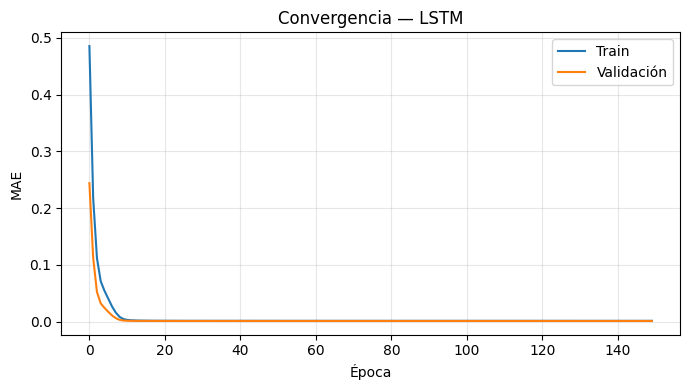

In [9]:
graficar_convergencia(hist_lstm, 'LSTM')
resultado_lstm = evaluar_modelo(modelo_lstm, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='LSTM')
print(resultado_lstm)


## 1.5 Modelo Conv1D

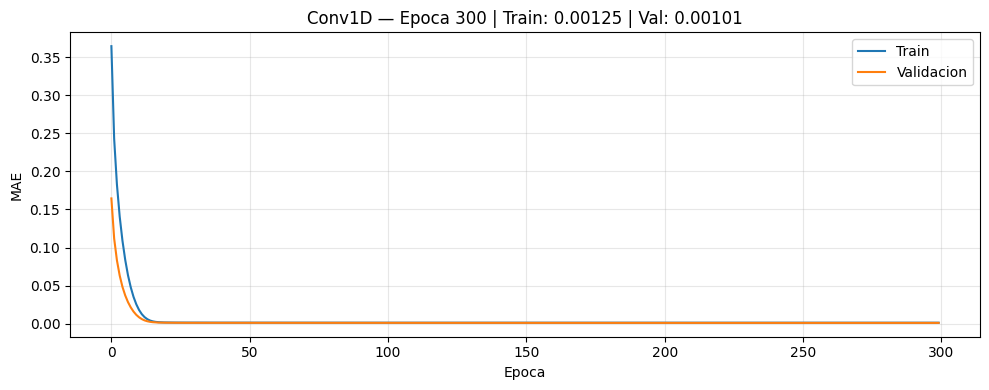

  → Pesos restaurados de epoca 299 (val_loss = 0.00100)


In [10]:
modelo_conv = construir_conv1d_v16_E(X_train.shape[1:], y_train.shape[1])
modelo_conv.summary()
callbacks_conv1d = [
    MejoresPesos(),
    ReduceLROnPlateau(factor=0.5, patience=10, min_lr=1e-6, verbose=0),
    LivePlot('Conv1D'),
]
hist_conv = fit_interrumpible(
    modelo_conv, X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=300, batch_size=128,
    callbacks=callbacks_conv1d, verbose=0)


{'modelo': 'Conv1D', 'mae_train': 0.001239193385743499, 'mae_val': 0.0009962086920067353, 'mae_test': 0.001278554035033097, 'n_params': 2813}


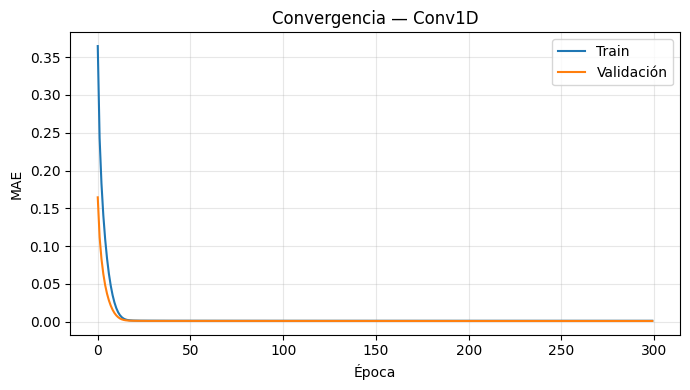

In [11]:
graficar_convergencia(hist_conv, 'Conv1D')
resultado_conv = evaluar_modelo(modelo_conv, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Conv1D')
print(resultado_conv)


## 1.6 Modelo Mixto (Conv1D + LSTM)

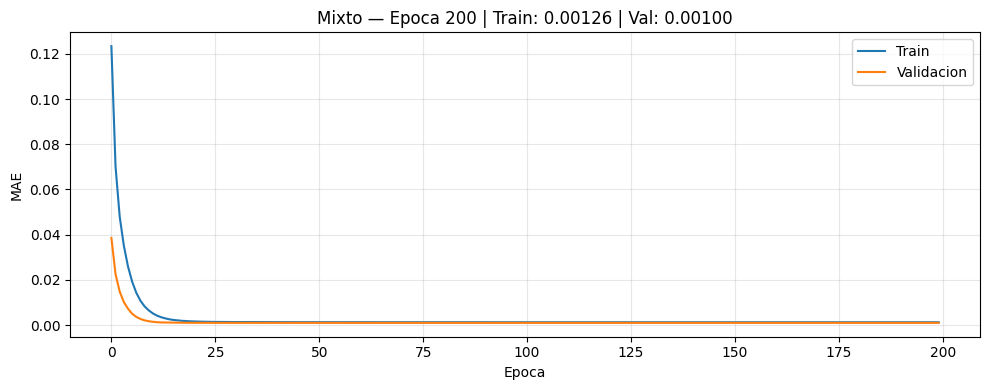

  → Pesos restaurados de epoca 40 (val_loss = 0.00099)


In [12]:
modelo_mixto = construir_mixto_v17_E(X_train.shape[1:], y_train.shape[1])
modelo_mixto.summary()
callbacks_mixto = [
    MejoresPesos(),
    ReduceLROnPlateau(factor=0.5, patience=10, min_lr=1e-6, verbose=0),
    LivePlot('Mixto'),
]
hist_mixto = fit_interrumpible(
    modelo_mixto, X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200, batch_size=128,
    callbacks=callbacks_mixto, verbose=0)


{'modelo': 'Mixto', 'mae_train': 0.0012455961602338772, 'mae_val': 0.000989728854376055, 'mae_test': 0.0012730179869344194, 'n_params': 4103}


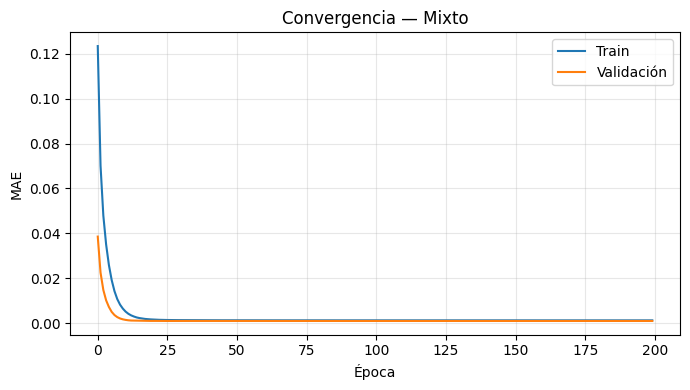

In [13]:
graficar_convergencia(hist_mixto, 'Mixto')
resultado_mixto = evaluar_modelo(modelo_mixto, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Mixto')
print(resultado_mixto)


## 1.7 Resumen de competicion y guardado

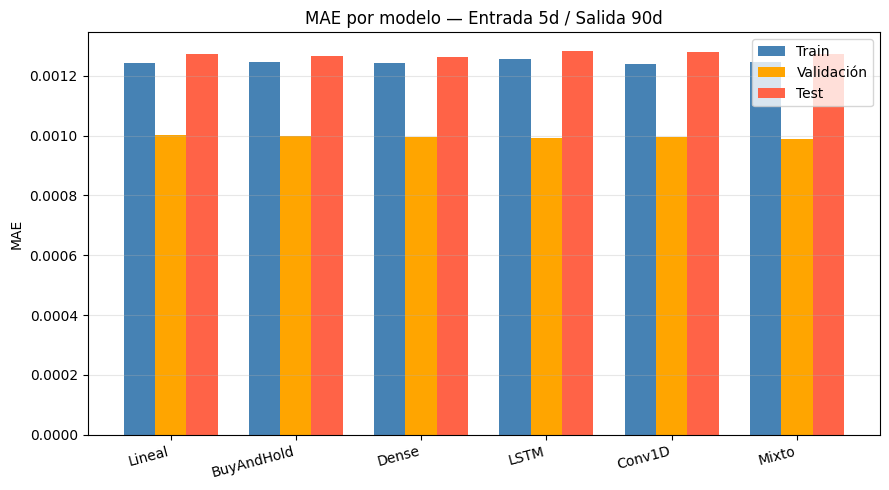

Resultados [competicion] guardados en: ../resultados/metricas/ent05_sal90.json


,mae_train,mae_val,mae_test,n_params
modelo,,,,
Lineal,0.001241,0.001002,0.001273,0
BuyAndHold,0.001246,0.000998,0.001265,0
Dense,0.001243,0.000995,0.001263,19991
LSTM,0.001254,0.000990,0.001281,9191
Conv1D,0.001239,0.000996,0.001279,2813
Mixto,0.001246,0.000990,0.001273,4103


In [14]:
resultados_competicion = [
    resultado_lineal, resultado_bah,
    resultado_dense, resultado_lstm,
    resultado_conv,  resultado_mixto,
]
graficar_barras_mae(resultados_competicion, VENTANA_ENTRADA, VENTANA_SALIDA)
guardar_resultados(resultados_competicion, VENTANA_ENTRADA, VENTANA_SALIDA, seccion='competicion')
display(pd.DataFrame(resultados_competicion).set_index('modelo').round(6))


---
# PARTE 2 — Investigacion
Preprocesado del Taller B3-T1 (Lopez de Prado):
1. **FFD** sobre log-retornos (Snippets 5.3-5.4, *Advances in Financial ML* 2018)
2. **Denoising Marchenko-Pastur** (*ML for Asset Managers* 2020)
3. **StandardScaler** ajustado solo sobre train


## 2.1 Diferenciacion fraccional (FFD)
Se aplica sobre **log-retornos** con ventana maxima de 500 pasos para
garantizar que siempre haya suficientes observaciones tras la transformacion.


In [15]:
# ── Snippet 5.3: pesos FFD con ventana maxima ───────────────────────────
def get_weights_ffd(d, threshold=1e-5, max_width=None):
    """Pesos para diferenciacion fraccional FFD. max_width limita la ventana."""
    w = [1.0]; k = 1
    while True:
        w_k = -w[-1] * (d - k + 1) / k
        if abs(w_k) < threshold:
            break
        w.append(w_k); k += 1
        if max_width and len(w) >= max_width:
            break
    return np.array(w[::-1])

# ── Snippet 5.4: aplicar FFD ─────────────────────────────────────────────
def frac_diff_ffd(series, d, threshold=1e-5, max_width=None):
    """Aplica FFD a una pd.Series. max_width trunca la ventana de pesos."""
    if max_width is None:
        max_width = len(series)          # no exceder la longitud de la serie
    weights = get_weights_ffd(d, threshold, max_width=max_width)
    width = len(weights)
    if width > len(series):
        return pd.Series(dtype=float)    # serie demasiado corta
    vals = series.values
    # Usar lista en lugar de dict para evitar desalineacion con DatetimeIndex
    result_vals = [
        np.dot(weights, vals[i - width + 1 : i + 1])
        for i in range(width - 1, len(vals))
    ]
    return pd.Series(result_vals, index=series.index[width - 1:])

def encontrar_d_minimo(serie, d_values=None, threshold=1e-5, pvalue=0.05):
    """
    Encuentra el minimo d que hace la serie estacionaria (ADF p-value < pvalue).
    Usa max_width = min(500, len(serie)//2) para que la ventana de pesos nunca
    consuma la serie completa y siempre queden observaciones suficientes.
    """
    if d_values is None:
        d_values = np.arange(0.1, 1.01, 0.1).round(1)
    serie_limpia = serie.replace([np.inf, -np.inf], np.nan).dropna()
    max_w = min(500, len(serie_limpia) // 2)   # ventana maxima: 500 o mitad de la serie
    for d in d_values:
        serie_diff = frac_diff_ffd(serie_limpia, d, threshold, max_width=max_w)
        serie_diff = serie_diff.replace([np.inf, -np.inf], np.nan).dropna()
        if len(serie_diff) < 20:
            continue
        try:
            adf_pval = adfuller(serie_diff, autolag='AIC')[1]
        except Exception:
            continue
        if adf_pval < pvalue:
            return d, frac_diff_ffd(serie_limpia, d, threshold, max_width=max_w)
    # Fallback: d=1 (primera diferencia), siempre estacionaria para retornos
    return 1.0, frac_diff_ffd(serie_limpia, 1.0, threshold, max_width=max_w)


d optimos por activo:
0.1    23
Name: count, dtype: int64

Forma tras FFD: (15691, 23)


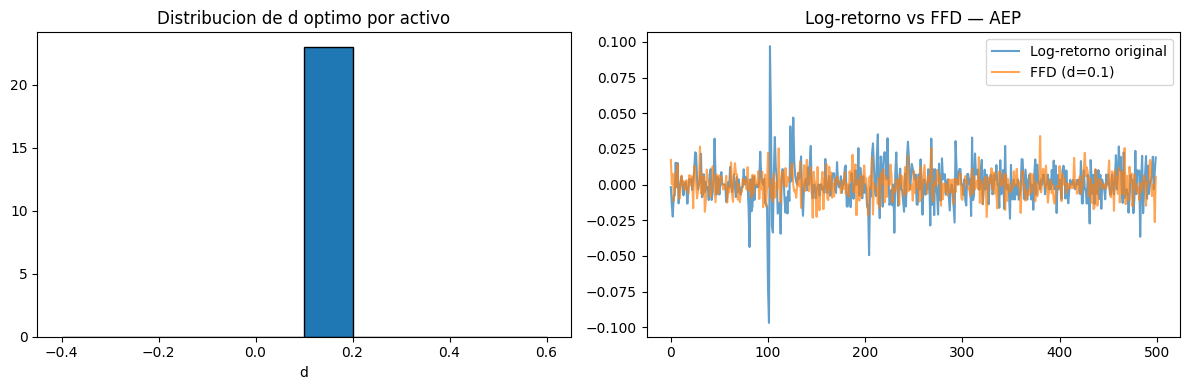

In [16]:
# FFD aplicada directamente sobre log-retornos.
# max_width=500 garantiza que la ventana de pesos no consuma la serie entera.

d_values = np.arange(0.1, 1.01, 0.1).round(1)
retornos_ffd = {}
d_optimos = {}

for ticker in retornos.columns:
    d_opt, serie_ffd = encontrar_d_minimo(retornos[ticker], d_values)
    d_optimos[ticker] = d_opt
    retornos_ffd[ticker] = serie_ffd

df_ffd = pd.DataFrame(retornos_ffd).dropna()
df_ffd = df_ffd.loc[:, df_ffd.std() > 1e-10]  # eliminar columnas constantes

print('d optimos por activo:')
print(pd.Series(d_optimos).value_counts().sort_index())
print(f'\nForma tras FFD: {df_ffd.shape}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(list(d_optimos.values()), bins=10, edgecolor='black')
axes[0].set_title('Distribucion de d optimo por activo')
axes[0].set_xlabel('d')
ticker_ej = retornos.columns[0]
axes[1].plot(retornos[ticker_ej].values[:500],  label='Log-retorno original', alpha=0.7)
axes[1].plot(df_ffd[ticker_ej].values[:500],    label=f'FFD (d={d_optimos[ticker_ej]})', alpha=0.7)
axes[1].set_title(f'Log-retorno vs FFD — {ticker_ej}')
axes[1].legend()
plt.tight_layout(); plt.show()


## 2.2 Denoising Marchenko-Pastur
Fuente: Lopez de Prado (2020). La funcion incluye fallbacks para casos
donde la matriz no converge numericamente.


In [17]:
def mp_pdf(var, q, pts=1000):
    lmin = var * (1 - np.sqrt(1 / q)) ** 2
    lmax = var * (1 + np.sqrt(1 / q)) ** 2
    x = np.linspace(lmin, lmax, pts)
    pdf = q / (2 * np.pi * var * x) * np.sqrt(np.maximum((lmax - x) * (x - lmin), 0))
    return x, pdf, lmax

def fit_kde(obs, bwidth=None, x=None):
    # bwidth adaptativo: 10% del rango de los datos
    if bwidth is None:
        r = obs.max() - obs.min()
        bwidth = max(0.01, r * 0.10)
    kde = KernelDensity(bandwidth=bwidth).fit(obs.reshape(-1, 1))
    if x is None:
        x = np.linspace(obs.min(), obs.max(), 1000)
    return x, np.exp(kde.score_samples(x.reshape(-1, 1)))

def err_pdfs(var, evals, q):
    if var <= 0:
        return 1e10
    lmin = var * (1 - np.sqrt(1 / q)) ** 2
    lmax = var * (1 + np.sqrt(1 / q)) ** 2
    if lmax <= lmin:
        return 1e10
    x_mp, pdf_mp, _ = mp_pdf(var, q)
    _, pdf_kde = fit_kde(evals, x=x_mp)
    return float(np.sum((pdf_kde - pdf_mp) ** 2))

def find_max_eval(evals, q):
    # Normalizar eigenvalues para que el rango de busqueda sea significativo
    evals_flat = evals.flatten()
    evals_mean = evals_flat.mean()
    if evals_mean <= 0:
        evals_mean = 1.0
    evals_norm = evals_flat / evals_mean
    # Buscar var en [0.01, 3] sobre datos normalizados
    best_sse, best_var = np.inf, 1.0
    for var in np.linspace(0.01, 3.0, 60):
        sse = err_pdfs(var, evals_norm, q)
        if sse < best_sse:
            best_sse, best_var = sse, var
    # Refinamiento fino alrededor del mejor
    lo, hi = max(0.001, best_var * 0.5), best_var * 2.0
    try:
        from scipy.optimize import minimize_scalar
        res = minimize_scalar(err_pdfs, bounds=(lo, hi), method='bounded',
                              args=(evals_norm, q))
        if res.success and res.fun < best_sse:
            best_var = res.x
    except Exception:
        pass
    # lmax en escala original
    _, _, lmax_norm = mp_pdf(best_var, q)
    return lmax_norm * evals_mean

def denoised_corr(evals, evecs, n_signal):
    ev = evals.copy()
    noise = ev[n_signal:]
    if len(noise) > 0:
        ev[n_signal:] = noise.mean()
    corr = evecs @ np.diag(ev) @ evecs.T
    diag = np.sqrt(np.diag(corr))
    diag[diag == 0] = 1.0
    corr = corr / np.outer(diag, diag)
    np.fill_diagonal(corr, 1.0)
    return corr

def aplicar_denoising(returns_df):
    """
    Denoising Marchenko-Pastur sobre la matriz de covarianza.
    Devuelve (df_limpio, n_signal, lmax).
    """
    df = returns_df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(axis=1, how='any')
    df = df.loc[:, df.std() > 1e-10]

    if df.shape[1] < 2 or df.shape[0] < df.shape[1] + 5:
        return returns_df, 0, 1.0

    cov = df.cov().values
    if np.isnan(cov).any() or np.isinf(cov).any():
        return returns_df, 0, 1.0

    N = cov.shape[0]
    T = df.shape[0]
    q = T / N

    std = np.sqrt(np.diag(cov))
    std[std == 0] = 1.0
    corr = np.clip(cov / np.outer(std, std), -1, 1)
    np.fill_diagonal(corr, 1.0)

    try:
        evals, evecs = np.linalg.eigh(corr)
    except np.linalg.LinAlgError:
        print('AVISO: eigh no convergio, se devuelven datos sin denoising')
        return returns_df, 0, 1.0

    # eigh devuelve orden ascendente; invertir para descendente
    idx = np.argsort(evals)[::-1]
    evals, evecs = evals[idx], evecs[:, idx]
    evals = np.maximum(evals, 1e-10)   # evitar eigenvalues negativos por precision

    lmax = find_max_eval(evals.reshape(-1, 1), q)
    n_signal = max(1, min(N - 1, int(np.sum(evals > lmax))))

    corr_clean = denoised_corr(evals, evecs, n_signal)
    corr_clean = np.clip(corr_clean, -1, 1)
    np.fill_diagonal(corr_clean, 1.0)

    cov_clean = corr_clean * np.outer(std, std)
    cov_clean = (cov_clean + cov_clean.T) / 2 + 1e-6 * np.eye(N)

    try:
        L = np.linalg.cholesky(cov_clean)
        returns_clean = df.values @ np.linalg.inv(L).T
    except np.linalg.LinAlgError:
        print('AVISO: Cholesky no convergio, se devuelven datos sin transformar')
        returns_clean = df.values

    result = pd.DataFrame(returns_clean, index=df.index, columns=df.columns)
    for col in returns_df.columns:
        if col not in result.columns:
            result[col] = returns_df[col]
    return result[returns_df.columns], n_signal, lmax


Autovalores de senyal: 1 / 23
Lambda_max (Marchenko-Pastur): 6.4682


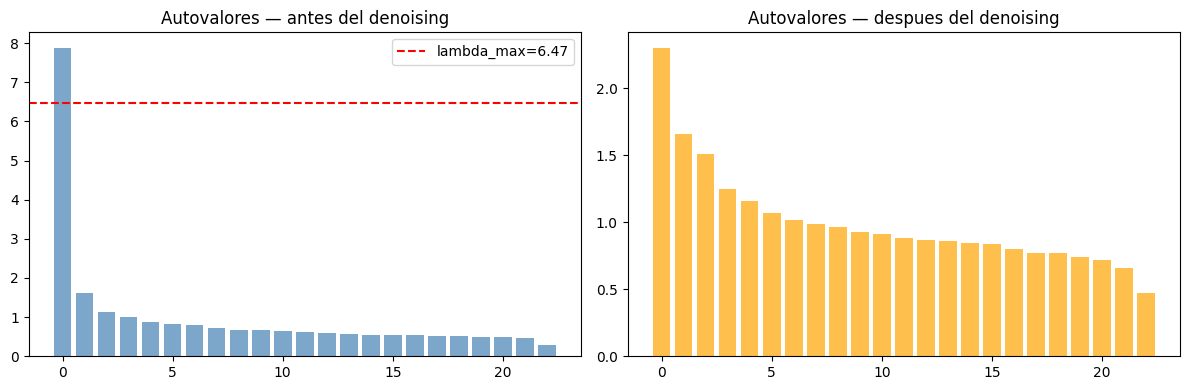

In [18]:
df_ffd_denoised, n_signal, lmax = aplicar_denoising(df_ffd)
print(f'Autovalores de senyal: {n_signal} / {df_ffd.shape[1]}')
print(f'Lambda_max (Marchenko-Pastur): {lmax:.4f}')

T, N = df_ffd.shape
corr_raw   = np.nan_to_num(df_ffd.corr().values, nan=0.0)
np.fill_diagonal(corr_raw, 1.0)
evals_raw   = np.sort(np.linalg.eigvalsh(corr_raw))[::-1]
corr_clean = np.nan_to_num(df_ffd_denoised.corr().values, nan=0.0)
np.fill_diagonal(corr_clean, 1.0)
evals_clean = np.sort(np.linalg.eigvalsh(corr_clean))[::-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(N), evals_raw,   color='steelblue', alpha=0.7)
axes[0].axhline(lmax, color='red', linestyle='--', label=f'lambda_max={lmax:.2f}')
axes[0].set_title('Autovalores — antes del denoising'); axes[0].legend()
axes[1].bar(range(N), evals_clean, color='orange', alpha=0.7)
axes[1].set_title('Autovalores — despues del denoising')
plt.tight_layout(); plt.show()


## 2.3 Construccion de ventanas con datos preprocesados

In [19]:
df_prep = df_ffd_denoised
print(f'Serie preprocesada: {df_prep.shape}')
X_p, y_p = create_time_series_data(df_prep, VENTANA_ENTRADA, VENTANA_SALIDA)
X_tr_p, X_val_p, X_ts_p, y_tr_p, y_val_p, y_ts_p = dividir_datos(X_p, y_p)
n_tr, v, ch = X_tr_p.shape
scaler = StandardScaler()
X_tr_flat  = scaler.fit_transform(X_tr_p.reshape(n_tr, -1))
X_val_flat = scaler.transform(X_val_p.reshape(X_val_p.shape[0], -1))
X_ts_flat  = scaler.transform(X_ts_p.reshape(X_ts_p.shape[0],  -1))
X_tr_3d  = X_tr_flat.reshape(n_tr, v, ch)
X_val_3d = X_val_flat.reshape(X_val_p.shape[0], v, ch)
X_ts_3d  = X_ts_flat.reshape(X_ts_p.shape[0],  v, ch)
print(f'Train: {X_tr_3d.shape}  Val: {X_val_3d.shape}  Test: {X_ts_3d.shape}')


Serie preprocesada: (15691, 23)
Train: (13335, 5, 23)  Val: (702, 5, 23)  Test: (1560, 5, 23)


## 2.4 Mejor modelo de Parte 1 re-entrenado con preprocesado

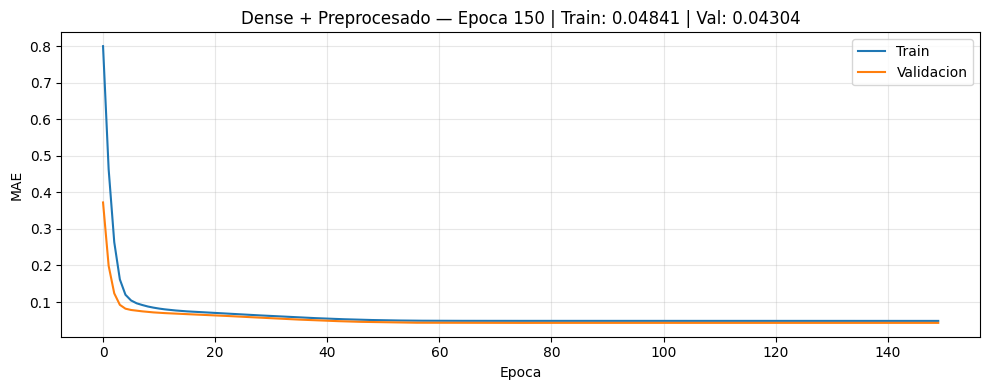

  → Pesos restaurados de epoca 76 (val_loss = 0.04300)
{'modelo': 'Dense_prep', 'mae_train': 0.04806515945758982, 'mae_val': 0.042641270140990735, 'mae_test': 0.05202974861243743, 'n_params': 19991}


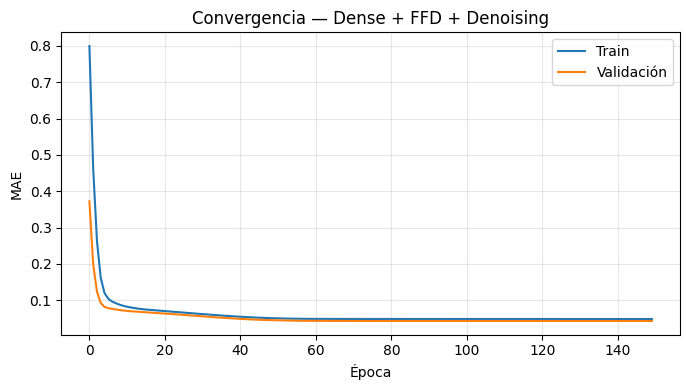

In [20]:
# Re-entrenamos el mejor modelo de Parte 1 con la MISMA arquitectura,
# pero sobre datos preprocesados (FFD + denoising Marchenko-Pastur).
# Asi la comparativa aisla el efecto del preprocesado, no el de cambiar de modelo.
df_comp = pd.DataFrame(resultados_competicion)
modelos_nn = ('Dense', 'LSTM', 'Conv1D', 'Mixto')
df_nn = df_comp[df_comp['modelo'].isin(modelos_nn)]
mejor_nombre = df_nn.loc[df_nn['mae_test'].idxmin(), 'modelo']
print(f'Mejor modelo Parte 1 (redes neuronales): {mejor_nombre}')

usa_plano = mejor_nombre == 'Dense'
constructores_prep = {
    'Dense':  lambda: construir_dense_v18_E(X_tr_flat.shape[1],   y_tr_p.shape[1]),
    'LSTM':   lambda: construir_recurrente_v18_E(X_tr_3d.shape[1:], y_tr_p.shape[1]),
    'Conv1D': lambda: construir_conv1d_v16_E(X_tr_3d.shape[1:],     y_tr_p.shape[1]),
    'Mixto':  lambda: construir_mixto_v17_E(X_tr_3d.shape[1:],      y_tr_p.shape[1]),
}
modelo_prep = constructores_prep[mejor_nombre]()
X_fit     = X_tr_flat  if usa_plano else X_tr_3d
X_fit_val = X_val_flat if usa_plano else X_val_3d
X_fit_ts  = X_ts_flat  if usa_plano else X_ts_3d

callbacks_prep = [
    MejoresPesos(),
    ReduceLROnPlateau(factor=0.5, patience=10, min_lr=1e-6, verbose=0),
    LivePlot(f'{mejor_nombre} + Preprocesado'),
]
hist_prep = fit_interrumpible(
    modelo_prep, X_fit, y_tr_p,
    validation_data=(X_fit_val, y_val_p),
    epochs=150, batch_size=128,
    callbacks=callbacks_prep, verbose=0)
graficar_convergencia(hist_prep, f'{mejor_nombre} + FFD + Denoising')
resultado_prep = evaluar_modelo(
    modelo_prep, X_fit, y_tr_p,
    X_fit_val, y_val_p, X_fit_ts, y_ts_p,
    nombre=f'{mejor_nombre}_prep')
print(resultado_prep)


## 2.5 Comparativa con/sin preprocesado y guardado

,mae_train,mae_val,mae_test,n_params
modelo,,,,
Dense,0.001243,0.000995,0.001263,19991
Dense_prep,0.048065,0.042641,0.052030,19991


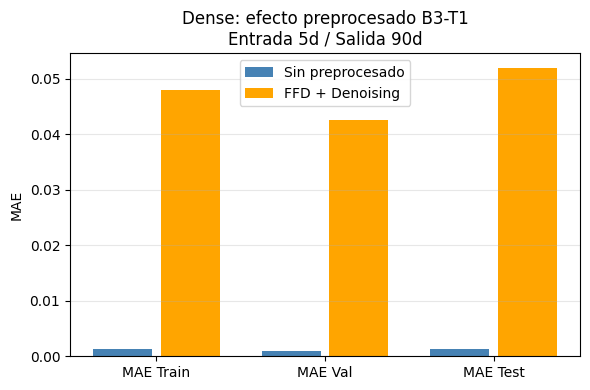

Variacion MAE test con preprocesado: -4019.5%
Resultados [investigacion] guardados en: ../resultados/metricas/ent05_sal90.json


In [21]:
resultado_sin_prep = df_comp[df_comp['modelo'] == mejor_nombre].iloc[0].to_dict()
comparativa = pd.DataFrame([resultado_sin_prep, resultado_prep])\
    .set_index('modelo')[['mae_train','mae_val','mae_test','n_params']].round(6)
display(comparativa)
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(3)
ax.bar(x - 0.2, [resultado_sin_prep['mae_train'],
                  resultado_sin_prep['mae_val'],
                  resultado_sin_prep['mae_test']], 0.35,
       label='Sin preprocesado', color='steelblue')
ax.bar(x + 0.2, [resultado_prep['mae_train'],
                  resultado_prep['mae_val'],
                  resultado_prep['mae_test']], 0.35,
       label='FFD + Denoising', color='orange')
ax.set_xticks(x)
ax.set_xticklabels(['MAE Train', 'MAE Val', 'MAE Test'])
ax.set_ylabel('MAE')
ax.set_title(f'{mejor_nombre}: efecto preprocesado B3-T1\n'
             f'Entrada {VENTANA_ENTRADA}d / Salida {VENTANA_SALIDA}d')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()
mejora = (resultado_sin_prep['mae_test'] - resultado_prep['mae_test']) / resultado_sin_prep['mae_test'] * 100
print(f'Variacion MAE test con preprocesado: {mejora:+.1f}%')
guardar_resultados([resultado_prep], VENTANA_ENTRADA, VENTANA_SALIDA, seccion='investigacion')
